# Proyecto Final: Venta Vehículos Proyecto

---
## Curso Análisis de Datos Junior
### ESTUD-IA
### Ruta: TECH

### Alcaldía de Medellín - Cymetria Group
### 2026

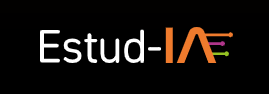

## Fuente Datos:

[Kaggle: Vehicle Sales Data](https://www.kaggle.com/datasets/syedanwarafridi/vehicle-sales-data)

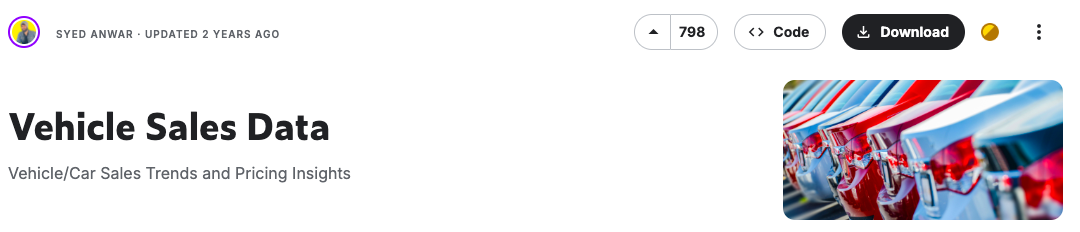

## Descripción del DataSet

The "Vehicle Sales and Market Trends Dataset" provides a comprehensive collection of information pertaining to the sales transactions of various vehicles. This dataset encompasses details such as the year, make, model, trim, body type, transmission type, VIN (Vehicle Identification Number), state of registration, condition rating, odometer reading, exterior and interior colors, seller information, Manheim Market Report (MMR) values, selling prices, and sale dates.

### Diccionario de Datos
Esta sección presenta el significado de cada variable del dataset.

1. **year**

`The manufacturing year of the vehicle.`

2. **make**

`The brand or manufacturer of the vehicle.`

3. **model**

`The specific model of the vehicle.`

4. **trim**

`Additional designation for the vehicle model.`

5. **body**

`The body type of the vehicle (e.g., SUV, Sedan).`

6. **transmission**

`The type of transmission in the vehicle (e.g., automatic).`

7. **vin**

`Vehicle Identification Number, a unique code for each vehicle.`

8. **state**

`The state where the vehicle is registered.`

9. **condition**

`Condition of the vehicle, possibly rated on a scale.`

10. **odometer**

`The mileage or distance traveled by the vehicle.`

11. **color**

`Exterior color of the vehicle.`

12. **interior**

`Interior color of the vehicle.`

13. **seller**

`The entity selling the vehicle.`

14. **mmr**

`Manheim Market Report, possibly indicating the estimated market value of the vehicle.`

15. **sellingprice**

`The price at which the vehicle was sold.`

16. **saledate**
`The date and time when the vehicle was sold.`




# 01 Establecer el entorno

## 1.1 Importar librerias 📚

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

#Conexión a Kaggle para importar el dataset
import kagglehub
import os

## 1.2 Cargar datos

### 🔵Local

In [ ]:
#Ruta
#path = '/content/car_prices.csv'

#Cargar datos
#df = pd.read_csv(path)

### 🔵 Kaggle API

#### Ruta Kagglehub

In [ ]:
path  = kagglehub.dataset_download("syedanwarafridi/vehicle-sales-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'vehicle-sales-data' dataset.
Path to dataset files: /kaggle/input/vehicle-sales-data


#### Lista de archivos

In [ ]:
# Lista de archivos y ordenados
archivos = sorted(os.listdir(path))
print("Archivos disponibles (ordenados):", archivos)

Archivos disponibles (ordenados): ['car_prices.csv']


#### Cargar datos

In [ ]:
#Seleccionar el primer archivo de la lista
#El 0 indica la posicion del archivo, en este caso el primero y unico que se tiene
nombre_archivo = archivos[0]

#Union entre la ruta de kagglehub con el archivo csv seleccionado
full_path = os.path.join(path, nombre_archivo)


#Lectura datos
df = pd.read_csv(full_path)

# 02 Diagnostico datos

## 2.1 Dimensiones del DataFrame

In [ ]:
print('Las dimensiones del DataFrame son:')
print(5*'-------')
print(f'Filas: {df.shape[0]}\nColumnas: {df.shape[1]}')

Las dimensiones del DataFrame son:
-----------------------------------
Filas: 558837
Columnas: 16


## 2.2 Primeras 5 filas

In [ ]:
df.head()

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


## 2.3 Ultimas 5 filas

In [ ]:
df.tail()

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
558832,2015,Kia,K900,Luxury,Sedan,NaN,knalw4d4xf6019304,in,45.0,18255.0,silver,black,avis corporation,35300.0,33000.0,Thu Jul 09 2015 07:00:00 GMT-0700 (PDT)
558833,2012,Ram,2500,Power Wagon,Crew Cab,automatic,3c6td5et6cg112407,wa,5.0,54393.0,white,black,i -5 uhlmann rv,30200.0,30800.0,Wed Jul 08 2015 09:30:00 GMT-0700 (PDT)
558834,2012,BMW,X5,xDrive35d,SUV,automatic,5uxzw0c58cl668465,ca,48.0,50561.0,black,black,financial services remarketing (lease),29800.0,34000.0,Wed Jul 08 2015 09:30:00 GMT-0700 (PDT)
558835,2015,Nissan,Altima,2.5 S,sedan,automatic,1n4al3ap0fc216050,ga,38.0,16658.0,white,black,enterprise vehicle exchange / tra / rental / t...,15100.0,11100.0,Thu Jul 09 2015 06:45:00 GMT-0700 (PDT)
558836,2014,Ford,F-150,XLT,SuperCrew,automatic,1ftfw1et2eke87277,ca,34.0,15008.0,gray,gray,ford motor credit company llc pd,29600.0,26700.0,Thu May 28 2015 05:30:00 GMT-0700 (PDT)


## 2.4 Información General y Tipos de Datos

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          558837 non-null  int64  
 1   make          548536 non-null  object 
 2   model         548438 non-null  object 
 3   trim          548186 non-null  object 
 4   body          545642 non-null  object 
 5   transmission  493485 non-null  object 
 6   vin           558833 non-null  object 
 7   state         558837 non-null  object 
 8   condition     547017 non-null  float64
 9   odometer      558743 non-null  float64
 10  color         558088 non-null  object 
 11  interior      558088 non-null  object 
 12  seller        558837 non-null  object 
 13  mmr           558799 non-null  float64
 14  sellingprice  558825 non-null  float64
 15  saledate      558825 non-null  object 
dtypes: float64(4), int64(1), object(11)
memory usage: 68.2+ MB


## 2.5 Datos Faltantes

In [ ]:
is_na = df.isna()

tabla_datos_nan = pd.DataFrame({'Total Datos Faltantes': is_na.sum(),
              '% Datos Faltantes': np.round((is_na.mean()*100),decimals = 2)})

tabla_datos_nan = tabla_datos_nan.sort_values(by = 'Total Datos Faltantes', ascending = False)
tabla_datos_nan

,Total Datos Faltantes,% Datos Faltantes
transmission,65352,11.69
body,13195,2.36
condition,11820,2.12
trim,10651,1.91
model,10399,1.86
make,10301,1.84
color,749,0.13
interior,749,0.13
odometer,94,0.02
mmr,38,0.01


## 2.6 Datos Duplicados ⛳

pendiente: validar si los duplicados de vin (el id) se quitan o no teniendo en cuenta que es un dataset de ventas, no eliminar ningun duplicado con subset.

In [ ]:
print(f'El DataFrame tiene un total de {df.duplicated().sum()} registros duplicados')

El DataFrame tiene un total de 0 registros duplicados


In [ ]:
#df.duplicated(subset = 'vin').sum()

## 2.7 Auditoria Variables NaN

## 🟠 **transmission**
---
`The type of transmission in the vehicle (e.g., automatic).`

###Hallazgos:

1. Se deja constancia los datos faltantes a imputar

**🤔posible solución:**  imputar por moda

2. Se encontró  una tercera caracteristica anomala `sedan`

**🤔posible solución:** reemplazar `sedan` y `Sedan` por datos faltantes e imputar con la moda.

In [ ]:
## Validar tipo de datos
print(f'El tipo de datos de la columna transmission es:\n {df['transmission'].dtype}')
print(10*'-----')
## Cantidad de nulos
print(f'La cantidad de nulos de la columna transmission es:\n {df['transmission'].isna().sum()}')
print(f'El % de nulos de la columna transmission es:\n {(df['transmission'].isna().mean()*100).round(2)}')
print(10*'-----')
## Valores Unicos
print(f'Los valores unicos de la columna transmission son:\n {df['transmission'].unique()}')
print(10*'-----')


El tipo de datos de la columna transmission es:
 object
--------------------------------------------------
La cantidad de nulos de la columna transmission es:
 65352
El % de nulos de la columna transmission es:
 11.69
--------------------------------------------------
Los valores unicos de la columna transmission son:
 ['automatic' nan 'manual' 'Sedan' 'sedan']
--------------------------------------------------


In [ ]:
transmission_count = df['transmission'].value_counts()   #tambien puedo usar .mul(100)
transmission_perc = (df['transmission'].value_counts(normalize=True)*100).round(4)

pd.DataFrame({
    'Cantidad Total': transmission_count,
    'Porcentaje': transmission_perc
    })

,Cantidad Total,Porcentaje
transmission,,
automatic,475915,96.4396
manual,17544,3.5551
sedan,15,0.0030
Sedan,11,0.0022


imputar moda sedan Sedan
llevar sedan a nan e imputar moda ✅

## 🟠 **body**
`The body type of the vehicle (e.g., SUV, Sedan).`

###Hallazgos:

1. Se encontró una cantidad de caracteristicas escritas en mayuscula o minuscula

**🤔posible solución:** Normalizar el texto como medida inicial

2. Se deja constancia los datos faltantes a imputar

**🤔posible solución:** imputar por moda

3. Hay una cantidad alta de categorias, que puede afectar una visualización.

**🤔posible solución:**  agrupar por categorias que facilite el análisis comparativo.

identificar manual y agrupar
por ciclos agrupar categorias con palabras similares ejm Sedan, G Sedan --> agrupado seria Sedan unicamente

In [ ]:
## Validar tipo de datos
print(f'El tipo de datos de la columna body es:\n {df['body'].dtype}')
print(10*'-----')
## Cantidad de nulos
print(f'La cantidad de nulos de la columna body es:\n {df['body'].isna().sum()}')
print(f'El % de nulos de la columna body es:\n {(df['body'].isna().mean()*100).round(2)}')
print(10*'-----')
## Valores Unicos
print(f'El total de Los valores unicos de la columna body son:\n {df['body'].nunique()}')
print(10*'-----')
print(f'Los valores unicos de la columna body son:\n {df['body'].unique()}')
print(10*'-----')

El tipo de datos de la columna body es:
 object
--------------------------------------------------
La cantidad de nulos de la columna body es:
 13195
El % de nulos de la columna body es:
 2.36
--------------------------------------------------
El total de Los valores unicos de la columna body son:
 87
--------------------------------------------------
Los valores unicos de la columna body son:
 ['SUV' 'Sedan' 'Convertible' 'Coupe' 'Wagon' 'Hatchback' 'Crew Cab'
 'G Coupe' 'G Sedan' 'Elantra Coupe' 'Genesis Coupe' 'Minivan' nan 'Van'
 'Double Cab' 'CrewMax Cab' 'Access Cab' 'King Cab' 'SuperCrew'
 'CTS Coupe' 'Extended Cab' 'E-Series Van' 'SuperCab' 'Regular Cab'
 'G Convertible' 'Koup' 'Quad Cab' 'CTS-V Coupe' 'sedan' 'G37 Convertible'
 'Club Cab' 'Xtracab' 'Q60 Convertible' 'CTS Wagon' 'convertible'
 'G37 Coupe' 'Mega Cab' 'Cab Plus 4' 'Q60 Coupe' 'Cab Plus'
 'Beetle Convertible' 'TSX Sport Wagon' 'Promaster Cargo Van'
 'GranTurismo Convertible' 'CTS-V Wagon' 'Ram Van' 'minivan' 'suv'

## 🟠 **condition**
`Condition of the vehicle, possibly rated on a scale.`

In [ ]:
## Validar tipo de datos
print(f'El tipo de datos de la columna condition es:\n {df['condition'].dtype}')
print(10*'-----')
## Cantidad de nulos
print(f'La cantidad de nulos de la columna condition es:\n {df['condition'].isna().sum()}')
print(f'El % de nulos de la columna condition es:\n {(df['condition'].isna().mean()*100).round(2)}')
print(10*'-----')
## Valores Unicos
print(f'Los valores unicos de la columna condition son:\n {df['condition'].unique()}')
print(10*'-----')
## Valor Máximo y Mínimo
print(f'El valor máximo de la columna condition es:\n {df['condition'].max()}')
print(f'El valor mínimo de la columna condition es:\n {df['condition'].min()}')

El tipo de datos de la columna condition es:
 float64
--------------------------------------------------
La cantidad de nulos de la columna condition es:
 11820
El % de nulos de la columna condition es:
 2.12
--------------------------------------------------
Los valores unicos de la columna condition son:
 [ 5. 45. 41. 43.  1. 34.  2. 42.  3. 48. nan 49. 17. 19. 29. 38. 44. 47.
 32.  4. 25. 37. 39. 31. 28. 46. 36. 35. 26. 21. 22. 27. 24. 33. 23. 15.
 16. 18. 12. 14. 11. 13.]
--------------------------------------------------
El valor máximo de la columna condition es:
 49.0
El valor mínimo de la columna condition es:
 1.0


por el ejercicio tomare una escala de 0 a 50

## 🟠 **trim**

`Additional designation for the vehicle model.`


In [ ]:
## Validar tipo de datos
print(f'El tipo de datos de la columna trim es:\n {df['trim'].dtype}')
print(10*'-----')
## Cantidad de nulos
print(f'La cantidad de nulos de la columna trim es:\n {df['trim'].isna().sum()}')
print(f'El % de nulos de la columna trim es:\n {(df['trim'].isna().mean()*100).round(2)}')
print(10*'-----')
## Valores Unicos
print(f'El total de los valores unicos de la columna trim son:\n {df['trim'].nunique()}')
print(10*'-----')
print(f'Los valores unicos de la columna trim son:\n {df['trim'].unique()}')
print(10*'-----')

El tipo de datos de la columna trim es:
 object
--------------------------------------------------
La cantidad de nulos de la columna trim es:
 10651
El % de nulos de la columna trim es:
 1.91
--------------------------------------------------
El total de los valores unicos de la columna trim son:
 1963
--------------------------------------------------
Los valores unicos de la columna trim son:
 ['LX' '328i SULEV' 'T5' ... 'pure' 'EWB' 'Power Wagon']
--------------------------------------------------


## 🟠 **model**

`The specific model of the vehicle.`

In [ ]:
## Validar tipo de datos
print(f'El tipo de datos de la columna model es:\n {df['model'].dtype}')
print(10*'-----')
## Cantidad de nulos
print(f'La cantidad de nulos de la columna model es:\n {df['model'].isna().sum()}')
print(f'El % de nulos de la columna model es:\n {(df['model'].isna().mean()*100).round(2)}')
print(10*'-----')
## Valores Unicos
print(f'El total de los valores unicos de la columna model son:\n {df['model'].nunique()}')
print(10*'-----')
print(f'Los valores unicos de la columna model son:\n {df['model'].unique()}')
print(10*'-----')

El tipo de datos de la columna model es:
 object
--------------------------------------------------
La cantidad de nulos de la columna model es:
 10399
El % de nulos de la columna model es:
 1.86
--------------------------------------------------
El total de los valores unicos de la columna model son:
 973
--------------------------------------------------
Los valores unicos de la columna model son:
 ['Sorento' '3 Series' 'S60' '6 Series Gran Coupe' 'Altima' 'M5' 'Cruze'
 'A4' 'Camaro' 'A6' 'Optima' 'Fusion' 'Sonata' 'Q5' '6 Series' 'Impala'
 '5 Series' 'A3' 'XC70' 'X5' 'SQ5' 'S5' 'Verano' 'Suburban' 'ELR' 'V60'
 'X6' 'ILX' 'K900' 'Malibu' 'RX 350' 'Versa' 'Elantra' 'Versa Note' 'A8'
 'X1' nan 'Enclave' 'TTS' '4 Series' 'Silverado 2500HD' 'MDX'
 'Silverado 1500' 'SRX' 'G Coupe' 'G Sedan' 'FX' 'Santa Fe' 'Genesis'
 'Equus' 'Sonata Hybrid' 'Accent' 'Veloster' 'Elantra Coupe' 'Azera'
 'Tucson' 'Genesis Coupe' 'Wrangler' 'S-Class' 'GS 350' 'Outlander'
 'C-Class' 'Mazda2' 'Rio' 'M' '370Z' '

## 🟠 **make**

`The brand or manufacturer of the vehicle.`

In [ ]:
## Validar tipo de datos
print(f'El tipo de datos de la columna make es:\n {df['make'].dtype}')
print(10*'-----')
## Cantidad de nulos
print(f'La cantidad de nulos de la columna make es:\n {df['make'].isna().sum()}')
print(f'El % de nulos de la columna make es:\n {(df['make'].isna().mean()*100).round(2)}')
print(10*'-----')
## Valores Unicos
print(f'El total de los valores unicos de la columna make son:\n {df['make'].nunique()}')
print(10*'-----')
print(f'Los valores unicos de la columna make son:\n {df['make'].unique()}')
print(10*'-----')

El tipo de datos de la columna make es:
 object
--------------------------------------------------
La cantidad de nulos de la columna make es:
 10301
El % de nulos de la columna make es:
 1.84
--------------------------------------------------
El total de los valores unicos de la columna make son:
 96
--------------------------------------------------
Los valores unicos de la columna make son:
 ['Kia' 'BMW' 'Volvo' 'Nissan' 'Chevrolet' 'Audi' 'Ford' 'Hyundai' 'Buick'
 'Cadillac' 'Acura' 'Lexus' 'Infiniti' 'Jeep' 'Mercedes-Benz' 'Mitsubishi'
 'Mazda' 'MINI' 'Land Rover' 'Lincoln' 'lincoln' 'Jaguar' 'Volkswagen'
 'Toyota' 'Subaru' 'Scion' 'Porsche' nan 'bmw' 'Dodge' 'FIAT' 'Chrysler'
 'ford' 'Ferrari' 'Honda' 'GMC' 'mitsubishi' 'Ram' 'smart' 'chevrolet'
 'Bentley' 'chrysler' 'pontiac' 'Pontiac' 'Saturn' 'Maserati' 'Mercury'
 'HUMMER' 'landrover' 'cadillac' 'land rover' 'mercedes' 'mazda' 'toyota'
 'lexus' 'gmc truck' 'honda' 'nissan' 'porsche' 'Saab' 'Suzuki' 'dodge'
 'subaru' 'Oldsmobil

##🟠 **color**

`Exterior color of the vehicle.`

In [ ]:
## Validar tipo de datos
print(f'El tipo de datos de la columna color es:\n {df['color'].dtype}')
print(10*'-----')
## Cantidad de nulos
print(f'La cantidad de nulos de la columna color es:\n {df['color'].isna().sum()}')
print(f'El % de nulos de la columna color es:\n {(df['color'].isna().mean()*100).round(2)}')
print(10*'-----')
## Valores Unicos
print(f'El total de los valores unicos de la columna color son:\n {df['color'].nunique()}')
print(10*'-----')
print(f'Los valores unicos de la columna color son:\n {df['color'].unique()}')
print(10*'-----')

El tipo de datos de la columna color es:
 object
--------------------------------------------------
La cantidad de nulos de la columna color es:
 749
El % de nulos de la columna color es:
 0.13
--------------------------------------------------
El total de los valores unicos de la columna color son:
 46
--------------------------------------------------
Los valores unicos de la columna color son:
 ['white' 'gray' 'black' 'red' 'silver' 'blue' 'brown' 'beige' 'purple'
 'burgundy' '—' 'gold' 'yellow' 'green' 'charcoal' nan 'orange'
 'off-white' 'turquoise' 'pink' 'lime' '4802' '9410' '1167' '2172' '14872'
 '12655' '15719' '6388' '16633' '11034' '2711' '6864' '339' '18384' '9887'
 '9837' '20379' '20627' '721' '6158' '2817' '5705' '18561' '2846' '9562'
 '5001']
--------------------------------------------------


## 🟠 **interior**

`Interior color of the vehicle.`


In [ ]:
## Validar tipo de datos
print(f'El tipo de datos de la columna interior es:\n {df['interior'].dtype}')
print(10*'-----')
## Cantidad de nulos
print(f'La cantidad de nulos de la columna interior es:\n {df['interior'].isna().sum()}')
print(f'El % de nulos de la columna interior es:\n {(df['interior'].isna().mean()*100).round(2)}')
print(10*'-----')
## Valores Unicos
print(f'El total de los valores unicos de la columna interior son:\n {df['interior'].nunique()}')
print(10*'-----')
print(f'Los valores unicos de la columna interior son:\n {df['interior'].unique()}')
print(10*'-----')

El tipo de datos de la columna interior es:
 object
--------------------------------------------------
La cantidad de nulos de la columna interior es:
 749
El % de nulos de la columna interior es:
 0.13
--------------------------------------------------
El total de los valores unicos de la columna interior son:
 17
--------------------------------------------------
Los valores unicos de la columna interior son:
 ['black' 'beige' 'tan' '—' 'gray' 'brown' 'burgundy' 'white' nan 'silver'
 'off-white' 'blue' 'red' 'yellow' 'green' 'purple' 'orange' 'gold']
--------------------------------------------------


## 🟠  **odometer**

`The mileage or distance traveled by the vehicle.`

In [ ]:
## Validar tipo de datos
print(f'El tipo de datos de la columna odometer es:\n {df['odometer'].dtype}')
print(10*'-----')
## Cantidad de nulos
print(f'La cantidad de nulos de la columna odometer es:\n {df['odometer'].isna().sum()}')
print(f'El % de nulos de la columna odometer es:\n {(df['odometer'].isna().mean()*100).round(2)}')
print(10*'-----')
## Valores Unicos
print(f'El total de los valores unicos de la columna odometer son:\n {df['odometer'].nunique()}')
print(10*'-----')
print(f'Los valores unicos de la columna odometer son:\n {df['odometer'].unique()}')
print(10*'-----')

El tipo de datos de la columna odometer es:
 float64
--------------------------------------------------
La cantidad de nulos de la columna odometer es:
 94
El % de nulos de la columna odometer es:
 0.02
--------------------------------------------------
El total de los valores unicos de la columna odometer son:
 172278
--------------------------------------------------
Los valores unicos de la columna odometer son:
 [ 16639.   9393.   1331. ... 204835. 111069. 262065.]
--------------------------------------------------


## 🟠 **mmr**

`Manheim Market Report, possibly indicating the estimated market value of the vehicle.`

In [ ]:
## Validar tipo de datos
print(f'El tipo de datos de la columna mmr es:\n {df['mmr'].dtype}')
print(10*'-----')
## Cantidad de nulos
print(f'La cantidad de nulos de la columna mmr es:\n {df['mmr'].isna().sum()}')
print(f'El % de nulos de la columna mmr es:\n {(df['mmr'].isna().mean()*100).round(2)}')
print(10*'-----')
## Valores Unicos
print(f'El total de los valores unicos de la columna mmr son:\n {df['mmr'].nunique()}')
print(10*'-----')
print(f'Los valores unicos de la columna mmr son:\n {df['mmr'].unique()}')
print(10*'-----')

El tipo de datos de la columna mmr es:
 float64
--------------------------------------------------
La cantidad de nulos de la columna mmr es:
 38
El % de nulos de la columna mmr es:
 0.01
--------------------------------------------------
El total de los valores unicos de la columna mmr son:
 1101
--------------------------------------------------
Los valores unicos de la columna mmr son:
 [ 20500.  20800.  31900. ... 182000. 119000. 164000.]
--------------------------------------------------


## 🟠 **saledate**
`The date and time when the vehicle was sold.`

In [ ]:
## Validar tipo de datos
print(f'El tipo de datos de la columna saledate es:\n {df['saledate'].dtype}')
print(10*'-----')
## Cantidad de nulos
print(f'La cantidad de nulos de la columna saledate es:\n {df['saledate'].isna().sum()}')
print(f'El % de nulos de la columna saledate es:\n {(df['saledate'].isna().mean()*100).round(4)}')
print(10*'-----')
## Valores Unicos
print(f'El total de los valores unicos de la columna saledate son:\n {df['saledate'].nunique()}')

El tipo de datos de la columna saledate es:
 object
--------------------------------------------------
La cantidad de nulos de la columna saledate es:
 12
El % de nulos de la columna saledate es:
 0.0021
--------------------------------------------------
El total de los valores unicos de la columna saledate son:
 3766


## 🟠 **sellingprice**

`The price at which the vehicle was sold.`

In [ ]:
## Validar tipo de datos
print(f'El tipo de datos de la columna sellingprice es:\n {df['sellingprice'].dtype}')
print(10*'-----')
## Cantidad de nulos
print(f'La cantidad de nulos de la columna sellingprice es:\n {df['sellingprice'].isna().sum()}')
print(f'El % de nulos de la columna sellingprice es:\n {(df['sellingprice'].isna().mean()*100).round(2)}')
print(10*'-----')
## Valores Unicos
print(f'El total de los valores unicos de la columna sellingprice son:\n {df['sellingprice'].nunique()}')
print(10*'-----')
print(f'Los valores unicos de la columna sellingprice son:\n {df['sellingprice'].unique()}')
print(10*'-----')
## Valor Máximo y Mínimo
print(f'El valor máximo de la columna sellingprice es:\n {df['sellingprice'].max()}')
print(f'El valor mínimo de la columna sellingprice es:\n {df['sellingprice'].min()}')

El tipo de datos de la columna sellingprice es:
 float64
--------------------------------------------------
La cantidad de nulos de la columna sellingprice es:
 12
El % de nulos de la columna sellingprice es:
 0.0
--------------------------------------------------
El total de los valores unicos de la columna sellingprice son:
 1887
--------------------------------------------------
Los valores unicos de la columna sellingprice son:
 [ 21500.  30000.  27750. ... 169000.  16550.  27840.]
--------------------------------------------------
El valor máximo de la columna sellingprice es:
 230000.0
El valor mínimo de la columna sellingprice es:
 1.0


## 🟠 **vin**

`Vehicle Identification Number, a unique code for each vehicle.`

In [ ]:
## Validar tipo de datos
print(f'El tipo de datos de la columna vin es:\n {df['vin'].dtype}')
print(10*'-----')
## Cantidad de nulos
print(f'La cantidad de nulos de la columna vin es:\n {df['vin'].isna().sum()}')
print(f'El % de nulos de la columna vin es:\n {(df['vin'].isna().mean()*100).round(4)}')
print(10*'-----')
## Valores Unicos
print(f'El total de los valores unicos de la columna vin son:\n {df['vin'].nunique()}')
print(10*'-----')
print(f'Los valores unicos de la columna vin son:\n {df['vin'].unique()}')

El tipo de datos de la columna vin es:
 object
--------------------------------------------------
La cantidad de nulos de la columna vin es:
 4
El % de nulos de la columna vin es:
 0.0007
--------------------------------------------------
El total de los valores unicos de la columna vin son:
 550297
--------------------------------------------------
Los valores unicos de la columna vin son:
 ['5xyktca69fg566472' '5xyktca69fg561319' 'wba3c1c51ek116351' ...
 '5uxzw0c58cl668465' '1n4al3ap0fc216050' '1ftfw1et2eke87277']


# 03 Tipos de datos

## 3.1 Fechas: saledate 📅

[Documentación: pandas.to_datetime](https://pandas.pydata.org/docs/reference/api/pandas.to_datetime.html)

### Validar tipo de dato

In [ ]:
print(f'El tipo de dato de saledate es: {df['saledate'].dtype}')

El tipo de dato de saledate es: object


In [ ]:
df['saledate'].head()

,saledate
0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


In [ ]:
df['saledate'].tail()

,saledate
558832,Thu Jul 09 2015 07:00:00 GMT-0700 (PDT)
558833,Wed Jul 08 2015 09:30:00 GMT-0700 (PDT)
558834,Wed Jul 08 2015 09:30:00 GMT-0700 (PDT)
558835,Thu Jul 09 2015 06:45:00 GMT-0700 (PDT)
558836,Thu May 28 2015 05:30:00 GMT-0700 (PDT)


### Procesamiento ▶

#### Crear nueva columna

Dado que para propósitos del ejercicio solamente requiero la fecha en formato `año-mes-día``, se crea una columna de nombre **saledate_clean** donde se va a llevar a cabo el procesamiento buscando obtener la fecha en el formato deseado

In [ ]:
#Dado que es un object, se filtra por posiciones para conocer la estructura deseada
df['saledate'].str[4:15].head()

,saledate
0,Dec 16 2014
1,Dec 16 2014
2,Jan 15 2015
3,Jan 29 2015
4,Dec 18 2014


In [ ]:
#Recortar los datos desde la cuarta posicion hasta la 15
df['saledate_clean'] = df['saledate'].str[4:15]
df['saledate_clean'].head()

,saledate_clean
0,Dec 16 2014
1,Dec 16 2014
2,Jan 15 2015
3,Jan 29 2015
4,Dec 18 2014


#### Convertir a formato fecha

La estructura que se tiene es:

- Mes abreviado (ejemplo: Dec)
- Día
- Año

Con lo cual en el metodo de Pandas `to_datetime()` se especifica en el parametro **format** lo siguiente:

- `%b` -> Mes abreviado
- `%d` -> Día numerado
- `%Y` -> Año numerado

En el caso de que hayan registros que no se puedan convertir a fechas, empleo **errors = 'coerce'**, asi quedan en formato **Not a Time** o **NaT**

##### Notas:

- Se debe poner los parametros de format en el mismo orden en que se tiene la fecha para poder leerlos.
- Si el mes estuviera numerado el parametro es --> `'%m'`

In [ ]:
df['saledate_clean'] = pd.to_datetime(df['saledate_clean'], format = '%b %d %Y', errors='coerce')
df['saledate_clean'].head()

,saledate_clean
0,2014-12-16
1,2014-12-16
2,2015-01-15
3,2015-01-29
4,2014-12-18


#### Comparativa de estructura

In [ ]:
print(f'El tipo de dato de saledate es: {df["saledate"].dtype}')
print(f'El tipo de dato de saledate_clean es: {df["saledate_clean"].dtype}')

El tipo de dato de saledate es: object
El tipo de dato de saledate_clean es: datetime64[ns]


In [ ]:
df[['saledate','saledate_clean']].head()

,saledate,saledate_clean
0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST),2014-12-16
1,Tue Dec 16 2014 12:30:00 GMT-0800 (PST),2014-12-16
2,Thu Jan 15 2015 04:30:00 GMT-0800 (PST),2015-01-15
3,Thu Jan 29 2015 04:30:00 GMT-0800 (PST),2015-01-29
4,Thu Dec 18 2014 12:30:00 GMT-0800 (PST),2014-12-18


In [ ]:
df[['saledate','saledate_clean']].tail()

,saledate,saledate_clean
558832,Thu Jul 09 2015 07:00:00 GMT-0700 (PDT),2015-07-09
558833,Wed Jul 08 2015 09:30:00 GMT-0700 (PDT),2015-07-08
558834,Wed Jul 08 2015 09:30:00 GMT-0700 (PDT),2015-07-08
558835,Thu Jul 09 2015 06:45:00 GMT-0700 (PDT),2015-07-09
558836,Thu May 28 2015 05:30:00 GMT-0700 (PDT),2015-05-28


#### Actualizar saledate

In [ ]:
df['saledate'] = df['saledate_clean']
print(f'El tipo de dato de saledate actualizado es: {df['saledate'].dtype}')

El tipo de dato de saledate actualizado es: datetime64[ns]


#### Remover saledate_clean

Dado que saledate ha sido actualizado se opta por eliminar la columna auxiliar **saledate_clean**.

In [ ]:
#Metodo drop para eliminar columnas, para ello se especifican los siguientes parametros:
## axis =1 --> hace referencia a que elimina por columnas
## inplace = True --> hace referencia a que sobreescribe el dataframe
df.drop('saledate_clean', axis=1, inplace=True)
print(f'La lista de columnas tras remover saledate_clean es:\n {df.columns.tolist()}')

La lista de columnas tras remover saledate_clean es:
 ['year', 'make', 'model', 'trim', 'body', 'transmission', 'vin', 'state', 'condition', 'odometer', 'color', 'interior', 'seller', 'mmr', 'sellingprice', 'saledate']


#### Validar Faltantes

Se observa que ha habido un aumento en la cantidad de faltantes para columna de `sale date`

A continuación dejo el registro:

|**Calculo** |**sale date sin tratar**| **sale data actualizada** | **Variación** |
| :--- | :--- | :---| :--- |
|** Conteo Faltantes**|  12 |  38 | 26 |
| **% Faltantes** |  0  | 0.01 % | 0.01% |

Implica un escenario de Trade-Off donde al limpiar la estructura de la columna hubo un aumento de nulos.


In [ ]:
is_na_date = df['saledate'].isna()

pd.DataFrame({
    'Total Faltantes': [is_na_date.sum()],
    '% Faltantes': [np.round((is_na_date.mean()*100), decimals = 2)]
}, index=['saledate']) #se debe definir el index, es decir la columna de la que quiero ver el calculo

,Total Faltantes,% Faltantes
saledate,38,0.01


fecha estandar, o dejarlo asi.
en power query podria filtar por nulos de saledate
considerar imputar por fechas cercanas

#### Auditoria

### Hallazgos

Hubo un aumento de datos nulos de 12 a 38, esto puede deberse a errores de formato del dataset original, o incluso como fue ingresada la información.

**🤔posible solución:**  imputar por moda, o imputar por la fecha del registro anterior.

En un escenario real, buscaria llevar una auditoria para buscar reducir el ingreso de datos erroneos, pero la imputación permite aproximarse a la realidad para llevar a cabo el analisis de datos.

### Coincidencia NaN: mmr, saledate

Esto fue un hallazgo en medio de la limpieza de las variables numericas:
- saledate
- mmr

Se encontró que donde **mmr* tiene **NaN**,  la columna **saledate** tiene ** NaT** en la mismas posiciones. Se deja la evidencia.

In [ ]:
print(df['mmr'].isna().sum())
print(df['saledate'].isna().sum())

38
38


In [ ]:
df_date_mmr = df[df['saledate'].isna() & df['mmr'].isna()]
display(df_date_mmr[['saledate','mmr']])

,saledate,mmr
306447,NaT,NaN
406524,NaT,NaN
408161,NaT,NaN
417835,NaT,NaN
421289,NaT,NaN
422358,NaT,NaN
424161,NaT,NaN
427040,NaT,NaN
427043,NaT,NaN
429644,NaT,NaN


In [ ]:
print(len(df_date_mmr))

38


## 3.2 Ver variables categoricas

In [ ]:
col_features = df.select_dtypes(include = 'object').columns.tolist()
col_features

['make',
 'model',
 'trim',
 'body',
 'transmission',
 'vin',
 'state',
 'color',
 'interior',
 'seller']

## 3.3 Ver variables numericas

In [ ]:
col_numeric = df.select_dtypes(include = 'number').columns.tolist()
col_numeric

['year', 'condition', 'odometer', 'mmr', 'sellingprice']

## 3.4 Fecha: year 📅



### Inspección

No tienen que ser iguales, dado que **year** representa el año de manufactura del vehiculo y **saledate** representa la fecha de venta

In [ ]:
# Validar correspondencia entre year y saledate en sus primeros 5 registros
df[['year','saledate']].head()

,year,saledate
0,2015,2014-12-16
1,2015,2014-12-16
2,2014,2015-01-15
3,2015,2015-01-29
4,2014,2014-12-18


In [ ]:
# Validar correspondencia entre year y saledate en sus ultimos 5 registros
df[['year','saledate']].tail()

,year,saledate
558832,2015,2015-07-09
558833,2012,2015-07-08
558834,2012,2015-07-08
558835,2015,2015-07-09
558836,2014,2015-05-28


### Auditoria

#### Hallazgos

A primera vista se evidencia que la columna `year` no coincide con `saledate`, lo cual esta bien. No obstante se observa casos como que el año de fabricación es 2015 pero fue vendido en 2014.

**🤔Decisión:** No necesariamente implica un error, podria ser vendido a manera de preventa. Y como no tiene datos nulos no es necesario modificarla.

In [ ]:
print(f'El tipo de dato de la columna year es {df['year'].dtype}')

El tipo de dato de la columna year es int64


In [ ]:
df['year'].head()

,year
0,2015
1,2015
2,2014
3,2015
4,2014


In [ ]:
## Comparativa entre año de fabricacion y fecha de venta
df[['year','saledate']].head()

,year,saledate
0,2015,2014-12-16
1,2015,2014-12-16
2,2014,2015-01-15
3,2015,2015-01-29
4,2014,2014-12-18


### Caso Hipotetico: cambio tipo de datos

Si en un caso hipotetico, las fechas tuvieran que ser iguales, podria seguir el siguiente procedimiento para extraer el año de fecha de venta, unicamente se deja como registro de exploración no se aplica en este contexto

In [ ]:
#Caso hipotetico
###
#Extraer de saledate el año para asignarlo a year
#df['year']  = pd.to_datetime(df['saledate']).dt.year
#df['year'].head()

In [ ]:
#print(f'El tipo de dato de la columna year es {df['year'].dtype}')

In [ ]:
# Cambiar a tipo de dato entero
#df['year'] = df['year'].astype('Int64')
#print(f'El tipo de dato de la columna year es {df['year'].dtype}')

In [ ]:
#df['year'].head()

#### Validar columnas: **year**, **saledate**

In [ ]:
## Validar cambios y que coincida saledate con year
#df[['year','saledate']].head()

In [ ]:
# Revisar los ultimos 5 registros
#df[['year','saledate']].tail()

## Fin situacion hipotetica de exploracion

# 04 Limpieza datos Faltantes 🧹

## 4.1 ✅ Fecha de Venta

Corresponde a las columnas:

- `saledate` --> tiene formato correcto de fecha

En esta sección se toma la decisión partiendo unicamente `saledate`

### Explicación decisión 🤔

Inicialmente se consideró utilizar el método de Pandas `f.fill()` que resulta útil para rellenar los datos faltantes aprovechando la fecha anterior al **Not a Time**.

[Documentación f.fill()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.ffill.html)

No obstante, se observó que el DataFrame no tiene registros de **fecha** en la columna **saledate** ordenados, por lo que generaria ruido. Se consideró ordenar la columna de forma descendente por **saledate** lo que implica cambiar de posición los **NaT** al final del DataFrame, con lo cuál se descarta este proceso que podria ser práctico en un escenario real.

Alternativamente, se pensó en la opción de imputar por la **moda** pero seria la misma situación de generar sesgos.

🤔 Decisión final:
---

Los NaT representan un 0.01% del total de registros en la columna **saledate**, con lo cual se decidió eliminar esas filas para prevenir sesgos.

### Eliminar Registros

In [ ]:
#Eliminar NaT de la columna saledate
# el parametro inplace permite sobreescribir el dataframe

df.dropna(subset = ['saledate'], inplace = True)

In [ ]:
# Validar datos faltantes
print(f'La cantidad de datos faltantes en la columna saledate es: {df["saledate"].isna().sum()}')
print(f'El % de datos faltantes en la columna saledate es: {np.round((df["saledate"].isna().mean()*100), decimals = 2)}%')


La cantidad de datos faltantes en la columna saledate es: 0
El % de datos faltantes en la columna saledate es: 0.0%


## 4.2 Variables Numericas

### Ver variables numericas

In [ ]:
col_numeric

['year', 'condition', 'odometer', 'mmr', 'sellingprice']

## ✅ **condition**

`Condition of the vehicle, possibly rated on a scale.`

### Explicación decisión 🤔

Se trata de una columna de califación del estado del vehículo, se ha optado por la mediana, porque se centra en el 50% de los datos, es decir el cuartil 2 (q2) y así se evitan sesgos que pueda generar la media a raíz de potenciales outliers (valores atípicos)

In [ ]:
is_na = df['condition'].isna()

pd.DataFrame({
    'Total Faltantes': [is_na.sum()],
    '% Faltantes': [np.round((is_na.mean()*100), decimals = 2)]
}, index=['condition'])

,Total Faltantes,% Faltantes
condition,11794,2.11


In [ ]:
print(f'El tipo de dato de la columna condition es:\n {df['condition'].dtype}')

El tipo de dato de la columna condition es:
 float64


### Imputar con la mediana

In [ ]:
#Calcular la mediana
median_condition = df['condition'].median()

#Imputar condition
df['condition'] = df['condition'].fillna(median_condition)

print(f'La columna condition tiene {df['condition'].isna().sum()} datos faltantes')

La columna condition tiene 0 datos faltantes


## ✅  **odometer**

`The mileage or distance traveled by the vehicle.`

### Explicación decisión 🤔

Se trata de una columna que hace referencia al Kilometraje o millaje que ha recorrido el vehiculo, para evitar sesgos de valores extremos se tomó la decisión de imputar con la mediana

In [ ]:
is_na = df['odometer'].isna()

pd.DataFrame({
    'Total Faltantes': [is_na.sum()],
    '% Faltantes': [np.round((is_na.mean()*100), decimals = 2)]
}, index=['odometer'])

,Total Faltantes,% Faltantes
odometer,94,0.02


In [ ]:
print(f'El tipo de dato de la columna odometer es:\n {df['odometer'].dtype}')

El tipo de dato de la columna odometer es:
 float64


### Imputar con la mediana

In [ ]:
#Calcular la mediana
median_odometer = df['odometer'].median()

#Imputar odometer
df['odometer'] = df['odometer'].fillna(median_odometer)

print(f'La columna odometer tiene {df['odometer'].isna().sum()} datos faltantes')

La columna odometer tiene 0 datos faltantes


## ✅ **mmr**

`Manheim Market Report, possibly indicating the estimated market value of the vehicle.`

### Explicación decisión 🤔

Un efecto de haber eliminado los registros NaT de fecha, tambien implicó borrar los NaT de **mmr** que tambien contaba con 38 datos faltantes

In [ ]:
df['mmr'].isna().sum()

np.int64(0)

In [ ]:
is_na = df['mmr'].isna()

pd.DataFrame({
    'Total Faltantes': [is_na.sum()],
    '% Faltantes': [np.round((is_na.mean()*100), decimals = 2)]
}, index=['mmr'])

,Total Faltantes,% Faltantes
mmr,0,0.0


## ✅ **sellingprice**

`The price at which the vehicle was sold.`

### Explicación decisión 🤔
Se encontró que al haber eliminado los registros de fecha los **12** registros faltantes de **saledate** fueron eliminados.

In [ ]:
is_na = df['sellingprice'].isna()

pd.DataFrame({
    'Total Faltantes': [is_na.sum()],
    '% Faltantes': [np.round((is_na.mean()*100), decimals = 2)]
}, index=['sellingprice'])

,Total Faltantes,% Faltantes
sellingprice,0,0.0


## 4.3 Tratamiento de Texto

Se utiliza un **ciclo for** para recorrer cada una de las columnas categoricas que previamente habia guardo en **col_features**. El proceso se divide en los siguientes pasos:

1. **Estandarizar:**

Asegurarse que todas esas columnas sean **string** con el siguiente método:

```python
as.type(str)
```
2. **Limpiar:**

Eliminar espacios al inicio y final de las categorias. Se utilizó el siguiente método:

```python
.str.strip()
```




3. **Normalizar:**

Se convierte las variables categoricas en minuscula, con el fin de reducir los valores únicos.

```python
.str.lower()
```

4. **Reemplazar nulos**

En un ejercicio inicial se observó que al ejecutar los pasos anteriores los `NaN (datos faltantes)` pasaban a ser texto definido como `nan`, con lo cual se emplea el siguiente método para asegurarse que estos mantengan su estatus de faltante para luego poder imputarlos.

```python
replace('nan', np.nan)
```

### Ver variables categoricas

In [ ]:
col_features

['make',
 'model',
 'trim',
 'body',
 'transmission',
 'vin',
 'state',
 'color',
 'interior',
 'seller']

### Tratamiento ciclo for

In [ ]:
# Con el fin de evitar procesos repetitivos se emplea un ciclo for

for col in col_features:
  df[col] = df[col].astype(str).str.strip().str.lower().replace('nan', np.nan)

## 4.4 Variables categoricas

### ✅ **make** 🟡
`The brand or manufacturer of the vehicle.`

#### Obtener moda

In [ ]:
## Obtener la moda de make
moda_make = df['make'].mode()[0]
print(f'La moda de make es: {moda_make}')

La moda de make es: ford


#### Imputar moda

In [ ]:
df['make'] = df['make'].fillna(moda_make)

In [ ]:
## Validar limpieza
print(f'La columna make tiene un total de {df['make'].isna().sum()} datos faltantes')

La columna make tiene un total de 0 datos faltantes


#### Valores unicos

In [ ]:
print(f'La columna make tiene {df['make'].nunique()} valores unicos')

La columna make tiene 66 valores unicos


In [ ]:
df['make'].unique()

array(['kia', 'bmw', 'volvo', 'nissan', 'chevrolet', 'audi', 'ford',
       'hyundai', 'buick', 'cadillac', 'acura', 'lexus', 'infiniti',
       'jeep', 'mercedes-benz', 'mitsubishi', 'mazda', 'mini',
       'land rover', 'lincoln', 'jaguar', 'volkswagen', 'toyota',
       'subaru', 'scion', 'porsche', 'dodge', 'fiat', 'chrysler',
       'ferrari', 'honda', 'gmc', 'ram', 'smart', 'bentley', 'pontiac',
       'saturn', 'maserati', 'mercury', 'hummer', 'landrover', 'mercedes',
       'gmc truck', 'saab', 'suzuki', 'oldsmobile', 'isuzu', 'dodge tk',
       'geo', 'rolls-royce', 'mazda tk', 'hyundai tk', 'mercedes-b', 'vw',
       'daewoo', 'chev truck', 'ford tk', 'plymouth', 'ford truck',
       'tesla', 'airstream', 'dot', 'aston martin', 'fisker',
       'lamborghini', 'lotus'], dtype=object)

### ✅ **model** 🟡

`The specific model of the vehicle.`

#### Obtener moda

In [ ]:
moda_model = df['model'].mode()[0]
print(f'La moda de model es: {moda_model}')

La moda de model es: altima


#### Imputar moda

In [ ]:
df['model'] = df['model'].fillna(moda_model)

In [ ]:
## Validar limpieza
print(f'La columna model tiene un total de {df['model'].isna().sum()} datos faltantes')

La columna model tiene un total de 0 datos faltantes


#### Valores unicos

In [ ]:
print(f'La columna model tiene {df['model'].nunique()} valores unicos')

La columna model tiene 851 valores unicos


In [ ]:
df['model'].unique()

array(['sorento', '3 series', 's60', '6 series gran coupe', 'altima',
       'm5', 'cruze', 'a4', 'camaro', 'a6', 'optima', 'fusion', 'sonata',
       'q5', '6 series', 'impala', '5 series', 'a3', 'xc70', 'x5', 'sq5',
       's5', 'verano', 'suburban', 'elr', 'v60', 'x6', 'ilx', 'k900',
       'malibu', 'rx 350', 'versa', 'elantra', 'versa note', 'a8', 'x1',
       'enclave', 'tts', '4 series', 'silverado 2500hd', 'mdx',
       'silverado 1500', 'srx', 'g coupe', 'g sedan', 'fx', 'santa fe',
       'genesis', 'equus', 'sonata hybrid', 'accent', 'veloster',
       'elantra coupe', 'azera', 'tucson', 'genesis coupe', 'wrangler',
       's-class', 'gs 350', 'outlander', 'c-class', 'mazda2', 'rio', 'm',
       '370z', 'soul', 'outlander sport', 'slk-class', 'es 350',
       'e-class', 'mazda3', 'cooper clubman', 'cooper', 'cx-9', 'forte',
       'compass', 'jx', 'rx 450h', 'lr4', 'mazda5', 'range rover evoque',
       'ls 460', 'glk-class', 'sportage', 'grand cherokee', 'mkx', 'mkt',
     

### ✅**trim**

`Additional designation for the vehicle model.`

#### Obtener moda

In [ ]:
moda_trim = df['trim'].mode()[0]
print(f'La moda de trim es: {moda_trim}')

La moda de trim es: base


#### Imputar moda

In [ ]:
df['trim'] = df['trim'].fillna(moda_trim)

In [ ]:
## Validar limpieza
print(f'La columna trim tiene un total de {df['trim'].isna().sum()} datos faltantes')

La columna trim tiene un total de 0 datos faltantes


#### Valores unicos

In [ ]:
print(f'La columna trim tiene {df['trim'].nunique()} valores unicos')

La columna trim tiene 1887 valores unicos


In [ ]:
df['trim'].unique()

array(['lx', '328i sulev', 't5', ..., '4.2 quattro spyder', 'ewb',
       'power wagon'], dtype=object)

### ✅**body**
`The body type of the vehicle (e.g., SUV, Sedan).`


#### Obtener moda

In [ ]:
moda_body = df['body'].mode()[0]
print(f'La moda de body es: {moda_body}')

La moda de body es: sedan


#### Imputar moda

In [ ]:
df['body'] = df['body'].fillna(moda_body)

In [ ]:
## Validar limpieza
print(f'La columna body tiene un total de {df['body'].isna().sum()} datos faltantes')

La columna body tiene un total de 0 datos faltantes


#### Valores unicos

In [ ]:
print(f'La columna body tiene {df['body'].nunique()} valores unicos')

La columna body tiene 45 valores unicos


In [ ]:
df['body'].unique()

array(['suv', 'sedan', 'convertible', 'coupe', 'wagon', 'hatchback',
       'crew cab', 'g coupe', 'g sedan', 'elantra coupe', 'genesis coupe',
       'minivan', 'van', 'double cab', 'crewmax cab', 'access cab',
       'king cab', 'supercrew', 'cts coupe', 'extended cab',
       'e-series van', 'supercab', 'regular cab', 'g convertible', 'koup',
       'quad cab', 'cts-v coupe', 'g37 convertible', 'club cab',
       'xtracab', 'q60 convertible', 'cts wagon', 'g37 coupe', 'mega cab',
       'cab plus 4', 'q60 coupe', 'cab plus', 'beetle convertible',
       'tsx sport wagon', 'promaster cargo van',
       'granturismo convertible', 'cts-v wagon', 'ram van', 'transit van',
       'regular-cab'], dtype=object)

### ✅ **transmission**
---
`The type of transmission in the vehicle (e.g., automatic).`

#### Validar valores unicos
Tras haber eliminado los registros de la columna de **saledate** se eliminaron tambien los registros que tenian las caracteristicas:

```python
[Sedan, sedan]

In [ ]:
df['transmission'].unique()

array(['automatic', nan, 'manual'], dtype=object)

#### Obtener moda

In [ ]:
moda_transmission = df['transmission'].mode()[0]
print(f'La moda de transmission es: {moda_transmission}')

La moda de transmission es: automatic


#### Imputar moda

In [ ]:
df['transmission'] = df['transmission'].fillna(moda_transmission)

In [ ]:
## Validar limpieza
print(f'La columna transmission tiene un total de {df['transmission'].isna().sum()} datos faltantes')

La columna transmission tiene un total de 0 datos faltantes


#### Valores unicos

In [ ]:
print(f'La columna transmission tiene {df['transmission'].nunique()} valores unicos')

La columna transmission tiene 2 valores unicos


In [ ]:
df['transmission'].unique()

array(['automatic', 'manual'], dtype=object)

### ✅**vin**

`Vehicle Identification Number, a unique code for each vehicle.`

#### Validar nulos

In [ ]:
print('vin tiene:',df['vin'].isna().sum(),'datos faltantes')

vin tiene: 0 datos faltantes


In [ ]:
## Validar limpieza
print(f'La columna vin tiene un total de {df['vin'].isna().sum()} datos faltantes')

La columna vin tiene un total de 0 datos faltantes


#### **Imputar: no registra**

Inicialmente se consideró eliminar los registros, pero se optó por imputar con no registra, ya que podria ser útil suponiendo que llegaran nuevos registros con esa situación y se hiciera el ejercicio de auditoria

In [ ]:
df['vin'] = df['vin'].fillna('no registra')

### ✅**color**

`Exterior color of the vehicle.`

#### Obtener moda

In [ ]:
moda_color = df['color'].mode()[0]
print(f'La moda de color es: {moda_color}')

La moda de color es: black


#### Imputar moda

In [ ]:
df['color'] = df['color'].fillna(moda_color)

In [ ]:
## Validar limpieza
print(f'La columna color tiene un total de {df['color'].isna().sum()} datos faltantes')

La columna color tiene un total de 0 datos faltantes


#### Valores unicos

In [ ]:
print(f'La columna color tiene {df['color'].nunique()} valores unicos')

La columna color tiene 20 valores unicos


In [ ]:
df['color'].unique()

array(['white', 'gray', 'black', 'red', 'silver', 'blue', 'brown',
       'beige', 'purple', 'burgundy', '—', 'gold', 'yellow', 'green',
       'charcoal', 'orange', 'off-white', 'turquoise', 'pink', 'lime'],
      dtype=object)

#### Corrección Valores unicos

Se observó una caracteristica incorrecta en **color**, marcada como `—`. Con lo cual se convirtio en **NaN** y posteriormente imputador con la moda

In [ ]:
# Hay una categoria que no es clara, por lo que se convierte en nan
df['color'] = df['color'].replace('—', np.nan)

In [ ]:
# Imputar Nan con moda
df['color'] = df['color'].fillna(moda_color)

In [ ]:
df['color'].unique()

array(['white', 'gray', 'black', 'red', 'silver', 'blue', 'brown',
       'beige', 'purple', 'burgundy', 'gold', 'yellow', 'green',
       'charcoal', 'orange', 'off-white', 'turquoise', 'pink', 'lime'],
      dtype=object)

### ✅**interior**

`Interior color of the vehicle.`

#### Obtener moda

In [ ]:
moda_interior = df['interior'].mode()[0]
print(f'La moda de interior es: {moda_interior}')

La moda de interior es: black


#### Imputar moda

In [ ]:
df['interior'] = df['interior'].fillna(moda_interior)

In [ ]:
## Validar limpieza
print(f'La columna interior tiene un total de {df['interior'].isna().sum()} datos faltantes')

La columna interior tiene un total de 0 datos faltantes


#### Valores unicos

In [ ]:
print(f'La columna interior tiene {df['interior'].nunique()} valores unicos')

La columna interior tiene 17 valores unicos


In [ ]:
df['interior'].unique()

array(['black', 'beige', 'tan', '—', 'gray', 'brown', 'burgundy', 'white',
       'silver', 'off-white', 'blue', 'red', 'yellow', 'green', 'purple',
       'orange', 'gold'], dtype=object)

#### Corrección valores únicos

In [ ]:
# Hay una categoria que no es clara, por lo que se convierte en nan
df['interior'] = df['interior'].replace('—', np.nan)

In [ ]:
# Imputar Nan con moda
df['interior'] = df['interior'].fillna(moda_interior)

In [ ]:
df['interior'].unique()

array(['black', 'beige', 'tan', 'gray', 'brown', 'burgundy', 'white',
       'silver', 'off-white', 'blue', 'red', 'yellow', 'green', 'purple',
       'orange', 'gold'], dtype=object)

In [ ]:
#validar valores nulos
df['interior'].isna().sum()

np.int64(0)

# 05 Outliers

## 5.1 Establecer Variables numericas

In [ ]:
col_numeric

['year', 'condition', 'odometer', 'mmr', 'sellingprice']

In [ ]:
cols_numeric_to_drop = ['year','mmr','sellingprice']
cols_numeric_to_drop

['year', 'mmr', 'sellingprice']

In [ ]:
# Establezco la lista de variables numericas en las cuales hare el proceso de deteccion y limpieza
# de outliers

col_numeric = [col for col in col_numeric if col not in cols_numeric_to_drop]

In [ ]:
# Validar que haya funcionado
col_numeric

['condition', 'odometer']

## 5.2 Boxplots

In [ ]:
col_numeric

['condition', 'odometer']

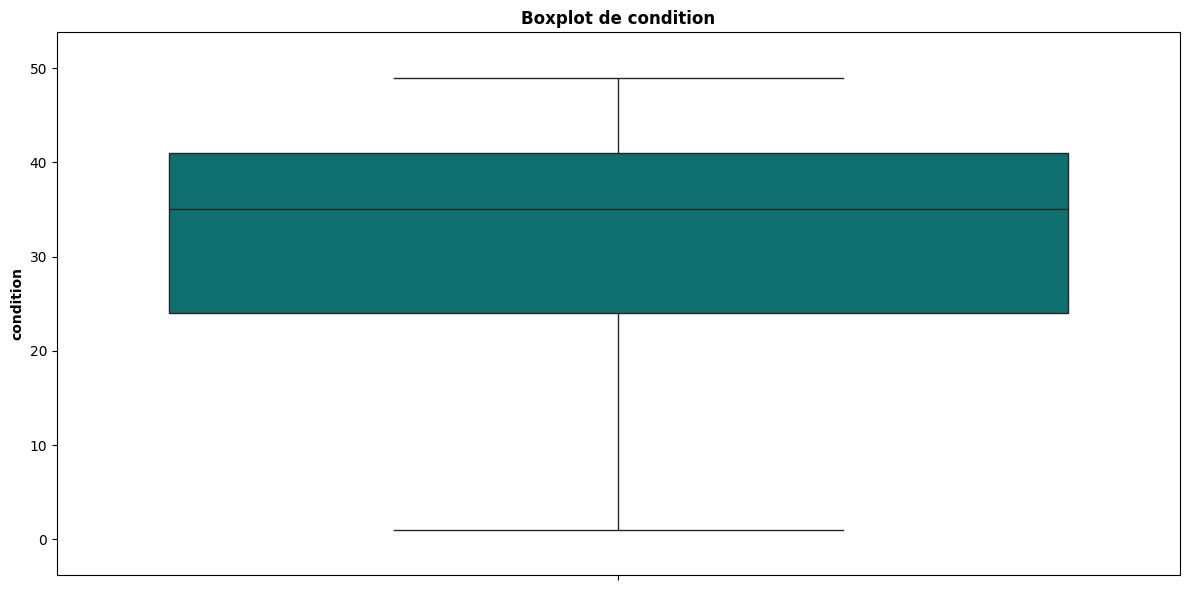

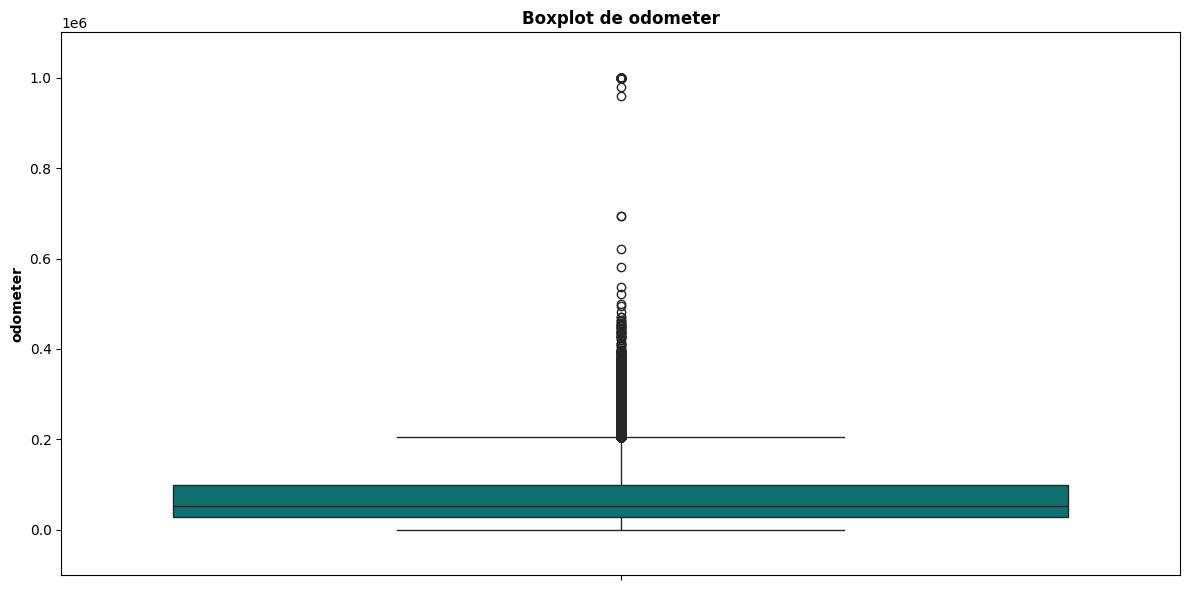

In [ ]:
for col in col_numeric:
  plt.figure(figsize = (12,6))
  sns.boxplot(data = df[col_numeric], y = col, color = 'teal')

  plt.title(f'Boxplot de {col}', fontweight = 'bold')
  plt.ylabel(col, fontweight = 'bold')

  plt.tight_layout()

  plt.margins(y = 0.10) # aumentar el eje 'y' en un 10%
  plt.show()

## 5.3 IQR

### Obtener cuartiles

In [ ]:
# Q1 (25% de los datos)
q1 = df[col_numeric].quantile(0.25)

# Q3 (75% de los datos)
q3 = df[col_numeric].quantile(0.75)

In [ ]:
q1

,0.25
condition,24.0
odometer,28378.0


In [ ]:
q3

,0.75
condition,41.0
odometer,99105.5


### IQR

In [ ]:
iqr = q3 - q1
iqr

,0
condition,17.0
odometer,70727.5


### Limite superior e inferior

In [ ]:
#Limite inferior
li = q1 - 1.5 * iqr

#Limite superior
ls = q3 + 1.5 * iqr

## 5.4 Función detección outliers

Documentación modulo **typing**
La utilidad en este caso es que se pueda considerar datos enteros y flotantes.

- [union_types](https://mypy.readthedocs.io/en/stable/kinds_of_types.html)

- [Type Hints in Python](https://towardsdatascience.com/type-hints-in-python-1c096f44f375/)

In [ ]:
#utilizo este modulo para ser explicito en usar int y float como parametro
from typing import Union

In [ ]:
# Función dinamica para detectar outliers
## Parametro Union para mostrar de forma explicita el tipo de datos que reconoce la funcion
## Feature hace referencia a los titulos de las columnas
## bool hace referencia a que si es un outlier lo tome como True(es outlier) o False (no es)
### el ls.loc[feauture]  y li.loc[feature]:
### hacen referencia a que compara el limite superior e inferior con los valores de las columnas

def is_outlier_iqr(x: Union[ int, float ], feature: str ) -> bool:
  if x > ls.loc[feature]:
    return True
  elif x < li.loc[feature]:
    return True
  else:
    return False #No es outlier

### Matriz outliers

In [ ]:
col_numeric

['condition', 'odometer']

In [ ]:
## Matriz de Outliers
## El objetivo es cuantificar cuantos outliers se tienen por columna

#crear un df vacio al cual se le añadiran los outliers
outliers_iqr = pd.DataFrame()

# Aplicar la función de detección
for ft in col_numeric:
  outliers_iqr[ft] = df[ft].apply(lambda x:is_outlier_iqr(x, feature = ft))

In [ ]:
## Generación de matriz de outliers
matriz_outliers = pd.DataFrame(data = {
    'Total Outliers': outliers_iqr.sum(),
    'Porcentaje Outliers': np.round((outliers_iqr.mean()*100), decimals = 2)
    })

# Ordenar de forma descendente los valores
matriz_outliers = matriz_outliers.sort_values(by = 'Total Outliers', ascending = False)
matriz_outliers

,Total Outliers,Porcentaje Outliers
odometer,10382,1.86
condition,0,0.00


In [ ]:
df.head()

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,kia,sorento,lx,suv,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,2014-12-16
1,2015,kia,sorento,lx,suv,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,2014-12-16
2,2014,bmw,3 series,328i sulev,sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,2015-01-15
3,2015,volvo,s60,t5,sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,2015-01-29
4,2014,bmw,6 series gran coupe,650i,sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,2014-12-18


### Seleccionar columnas con outliers

In [ ]:
outliers_iqr.sum().index #recordando que condition no tiene outliers

Index(['condition', 'odometer'], dtype='object')

In [ ]:
# Se debe excluir la columna condition ya que no tiene outliers
## establecemos la condicion de que en esta variable de outliers_fts
## solo guarda las columnas con outliers mayores a 0

outliers_fts = outliers_iqr.sum().index[outliers_iqr.sum() > 0]
print(f'El total de columnas con Outliers son: {len(outliers_fts)}')
outliers_fts

El total de columnas con Outliers son: 1


Index(['odometer'], dtype='object')

## 5.5 Copia al dataframe

In [ ]:
# saco una copia al dataframe por seguridad
# si funciona el proceso lo actualizo

df_copy = df.copy()

## 5.6 Función transformar outliers en NaN

### Definir funcion

In [ ]:
# Función para transformar datos nulos en NaN
# El tipo de retorno del dato que  puede devolver es float o NaN
def is_outlier_nan(x : Union[int,float], feature : str) -> Union[float, type(np.nan)]:
  # Asegurarse de que x no es NaN antes de compararlo con los límites.
  # Si es NaN, devuelve NaN para preservar el NaN existente.
  if pd.isna(x):
      return np.nan
  # Si x es un outlier (supera el límite superior o es menor al límite inferior), reemplazarlo con np.nan
  if x > ls.loc[feature] or x < li.loc[feature]:
    return np.nan
  else:
    return x # Si x no es un outlier, devuelve el valor original x

### Aplicar función

In [ ]:
# Aplicar la funcion para transformar outliers en faltantes
# Se itera por cada elemento

for ft in col_numeric:
  df_copy[ft] = df_copy[ft].apply(lambda x: is_outlier_nan(x, feature = ft))

In [ ]:
# Revisar rapidamente si hay NaN
df_copy[col_numeric].isna().sum().sort_values(ascending = False)

,0
odometer,10382
condition,0


## 5.7 Imputar Outliers con la mediana

In [ ]:
# Se asegura de hacer la imputacion en las columnas numericas
# que se habian guardado previamente como col_numeric
# se opto por la mediana ya que es menos sensible a los sesgos de valores extremos
df_copy.loc[:, col_numeric] = df_copy.loc[:, col_numeric].fillna(df_copy.loc[:, col_numeric].median())

# Convertir las columnas numéricas a float64 para asegurar el tipo de dato correcto
for col in col_numeric:
    df_copy[col] = df_copy[col].astype('float64')

In [ ]:
## Validar nuevamente si la imputación es correcta y no hay faltantes
df_copy.isna().sum().sort_values(ascending = False)

,0
year,0
make,0
model,0
trim,0
body,0
transmission,0
vin,0
state,0
condition,0
odometer,0


## 5.8 Sobreescribir DataFrame original

Dado que se ha asegurado la correcta implementación del proceso se sobreescribe el **df** original con la copia de seguridad

In [ ]:
df = df_copy

# 06 Descargar archivo

## 6.1 Validar Estructura

Para prevenir errores se observa la apariencia y tipo de datos del DataFrame que cumpla con lo esperado

In [ ]:
df.head()

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,kia,sorento,lx,suv,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,2014-12-16
1,2015,kia,sorento,lx,suv,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,2014-12-16
2,2014,bmw,3 series,328i sulev,sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,2015-01-15
3,2015,volvo,s60,t5,sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,2015-01-29
4,2014,bmw,6 series gran coupe,650i,sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,2014-12-18


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 558799 entries, 0 to 558836
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   year          558799 non-null  int64         
 1   make          558799 non-null  object        
 2   model         558799 non-null  object        
 3   trim          558799 non-null  object        
 4   body          558799 non-null  object        
 5   transmission  558799 non-null  object        
 6   vin           558799 non-null  object        
 7   state         558799 non-null  object        
 8   condition     558799 non-null  float64       
 9   odometer      558799 non-null  float64       
 10  color         558799 non-null  object        
 11  interior      558799 non-null  object        
 12  seller        558799 non-null  object        
 13  mmr           558799 non-null  float64       
 14  sellingprice  558799 non-null  float64       
 15  saledate      558799 n

## 6.2 Descargar Archivo

In [ ]:
# Guarda el df en un archivo csv sin guardar el indice de filas de Python
df.to_csv('ventas_vehiculos.csv', index = False)

# 07 Estadistica Descriptiva

## 7.1 Variables Numericas

In [ ]:
# Con el parametro include = 'number' indico el tipo de variable al cual obtener
# la estadistica descriptiva
df.describe(include = 'number').round(2)

,year,condition,odometer,mmr,sellingprice
count,558799.00,558799.00,558799.00,558799.00,558799.00
mean,2010.04,30.76,64706.39,13769.38,13611.36
std,3.97,13.28,46469.58,9679.97,9749.73
min,1982.00,1.00,1.00,25.00,1.00
25%,2007.00,24.00,28378.00,7100.00,6900.00
50%,2012.00,35.00,51023.00,12250.00,12100.00
75%,2013.00,41.00,95243.50,18300.00,18200.00
max,2015.00,49.00,205192.00,182000.00,230000.00


In [ ]:
# Se aprovecha que se habia creado una lista de variables numericas en pasos anteriores
df[col_numeric].describe().round(2)

,condition,odometer
count,558799.00,558799.00
mean,30.76,64706.39
std,13.28,46469.58
min,1.00,1.00
25%,24.00,28378.00
50%,35.00,51023.00
75%,41.00,95243.50
max,49.00,205192.00


## 7.2 Variables Categoricas

In [ ]:
df.describe(include = 'object').round(2)

,make,model,trim,body,transmission,vin,state,color,interior,seller
count,558799,558799,558799,558799,558799,558799,558799,558799,558799,558799
unique,66,851,1887,45,2,550284,38,19,16,14260
top,ford,altima,base,sedan,automatic,wbanv13588cz57827,fl,black,black,nissan-infiniti lt
freq,104297,29748,66491,254527,541255,5,82945,136403,262144,19693


## 7.3 Fecha

In [ ]:
df.describe(include = 'datetime')

,saledate
count,558799
mean,2015-03-06 03:34:12.409542400
min,2014-01-01 00:00:00
25%,2015-01-21 00:00:00
50%,2015-02-13 00:00:00
75%,2015-05-22 00:00:00
max,2015-07-21 00:00:00
